<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Assignment_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [2]:

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Training labels shape: (50000, 1)
Test labels shape: (10000, 1)


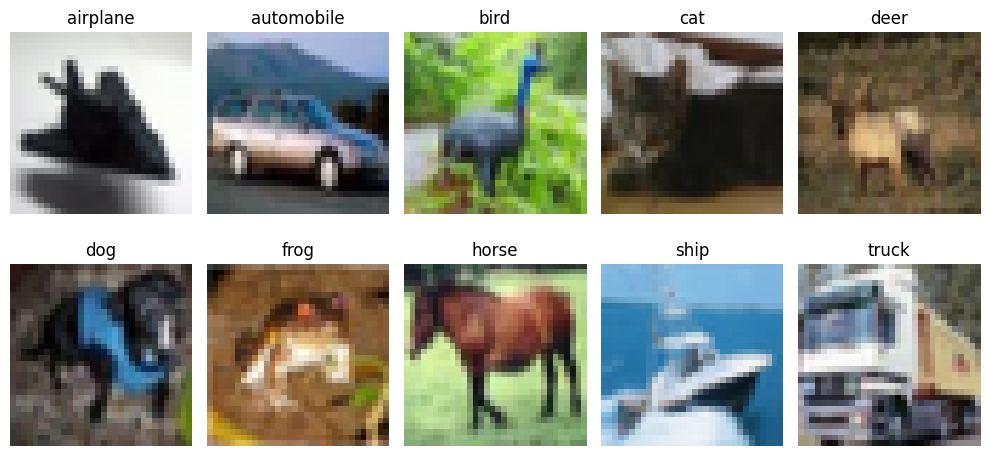

In [30]:
#  visualization
# Load data
(x_train, y_train), _ = cifar10.load_data()

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

# Collect one image per class
images = {}
for img, label in zip(x_train, y_train):
    label = label[0]
    if label not in images:
        images[label] = img
    if len(images) == 10:
        break

# Plot
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i])
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
# Flatten images (32x32x3 → 3072 features)
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),   # Convert image to 1D vector (3072)
    Dense(128, activation='relu'),      # Hidden layer
    Dense(64, activation='relu'),       # Optional second hidden layer
    Dense(10, activation='softmax')     # Output layer (10 classes)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Train the model on the training set using batch sizes of 32 or 64 for 10 to 20 epochs
# Train configuration
batch_size = 64   # try 32 or 64
epochs = 15       # between 10 and 20

# Normalize image data to be between 0 and 1 for Keras model
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

history = model.fit(
    x_train_normalized, y_train, # y_train does not need normalization
    validation_data=(x_test_normalized, y_test), # y_test does not need normalization
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True
)



Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3192 - loss: 1.8919 - val_accuracy: 0.3622 - val_loss: 1.7870
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3875 - loss: 1.7105 - val_accuracy: 0.3990 - val_loss: 1.6666
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4163 - loss: 1.6292 - val_accuracy: 0.4239 - val_loss: 1.6104
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4336 - loss: 1.5864 - val_accuracy: 0.4367 - val_loss: 1.5722
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4441 - loss: 1.5501 - val_accuracy: 0.4495 - val_loss: 1.5330
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4574 - loss: 1.5169 - val_accuracy: 0.4528 - val_loss: 1.5283
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4652 - loss: 1.4989 - val_accuracy: 0.4577 - val_loss: 1.5109
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4733 - loss: 1.4767 - val_ac

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4417 - loss: 196.4916
Test accuracy: 0.4417000114917755


In [11]:
#TensorFlow / Keras Evaluation/Predictions
y_prob = model.predict(x_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
# we compute  metrics

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision (macro):", precision)
print("Recall (macro):", recall)
print("F1-score (macro):", f1)

Accuracy: 0.4417
Precision (macro): 0.48390349129190946
Recall (macro): 0.4417000000000001
F1-score (macro): 0.42754490797468386


In [14]:
# full class report
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.40      0.67      0.50      1000
           1       0.61      0.58      0.60      1000
           2       0.43      0.22      0.29      1000
           3       0.29      0.23      0.26      1000
           4       0.61      0.15      0.24      1000
           5       0.27      0.58      0.37      1000
           6       0.63      0.28      0.39      1000
           7       0.52      0.54      0.53      1000
           8       0.50      0.69      0.58      1000
           9       0.57      0.47      0.51      1000

    accuracy                           0.44     10000
   macro avg       0.48      0.44      0.43     10000
weighted avg       0.48      0.44      0.43     10000



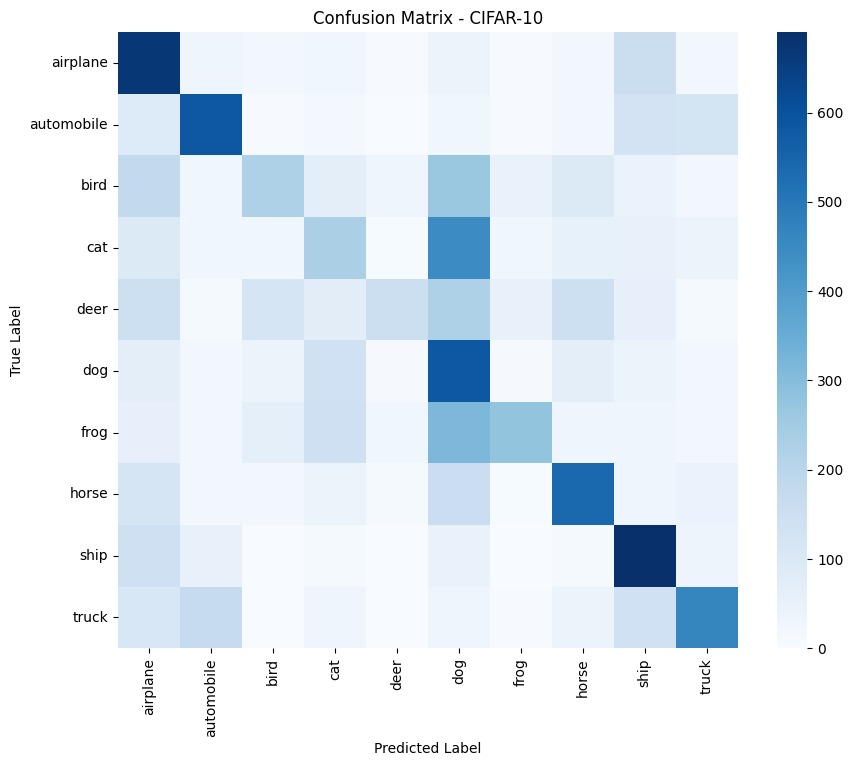

In [18]:
# Confusion matrix plot

cm = confusion_matrix(y_true, y_pred)

class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CIFAR-10")
plt.show()

In [20]:
#  increasing  layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(32, 32, 3)),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',   # try 'sgd', 'rmsprop'
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# SGD with momentum
optimizer = SGD(learning_rate=0.01, momentum=0.9)

# RMSprop
# optimizer = RMSprop(learning_rate=0.001)

# Adam (baseline)
# optimizer = Adam(learning_rate=0.001)

In [23]:
#data augmentation on model performance.

from tensorflow.keras import layers

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential([
    data_augmentation,                # <-- augmentation happens on the fly
    Flatten(input_shape=(32, 32, 3)),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',   # try 'sgd', 'rmsprop'
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
# we train same as before
history_aug = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    shuffle=True
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.1006 - loss: 13.0284 - val_accuracy: 0.0953 - val_loss: 2.3046
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.1009 - loss: 2.3036 - val_accuracy: 0.0953 - val_loss: 2.3028
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.0981 - loss: 2.3029 - val_accuracy: 0.0978 - val_loss: 2.3029
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.0983 - loss: 2.3028 - val_accuracy: 0.0977 - val_loss: 2.3030
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.0997 - loss: 2.3032 - val_accuracy: 0.0952 - val_loss: 2.3030
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.0983 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3030
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.1003 - loss: 2.3029 - val_accuracy: 0.0997 - val_loss: 2.3030
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.0989 - loss: 2.3029 -